In [1]:
!pip install vaderSentiment

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings("ignore")

# Load tweets
tweets = pd.read_csv(r"C:\Users\asawe\Documents\CR_Project\Tweets.csv")
print(f"Total raw tweets: {len(tweets)}")
print(f"\nColumns: {list(tweets.columns[:10])}")
print(f"\nLanguage distribution:\n{tweets['lang'].value_counts().head(10)}")

Total raw tweets: 9046

Columns: ['authorBannerImage', 'authorBio', 'authorCreatedAt', 'authorFollowers', 'authorFollowing', 'authorHandle', 'authorId', 'authorLocation', 'authorName', 'authorProfileImage']

Language distribution:
en    9046
Name: lang, dtype: int64


In [6]:
df = pd.read_csv(r"C:\Users\asawe\Documents\CR_Project\Tweets.csv")

In [7]:
df["date"] = pd.to_datetime(df["createdAt"])

seasons = {
    "Season 1": ("2025-12-01", "2026-01-05"),
    "Season 2": ("2026-01-05", "2026-02-02"),
    "Season 3": ("2026-02-02", "2026-03-02"),
    "Season 4": ("2026-03-02", "2026-04-06"),
    "Season 5": ("2026-04-06", "2026-05-04"),
    "Season 6": ("2026-05-04", "2026-06-01"),
}

def assign_season(date):
    for season, (start, end) in seasons.items():
        if pd.Timestamp(start, tz="UTC") <= date < pd.Timestamp(end, tz="UTC"):
            return season
    return "Outside range"

df["season"] = df["date"].apply(assign_season)
print("Tweets per season:")
print(df["season"].value_counts().sort_index())

Tweets per season:
Outside range    3113
Season 1         1384
Season 2         1299
Season 3         1206
Season 4          922
Season 5          516
Season 6          606
Name: season, dtype: int64


In [8]:
# Remove outside range tweets
df_clean = df[df["season"] != "Outside range"].copy()
print(f"Tweets after removing outside range: {len(df_clean)}")

# Remove very short tweets
df_clean = df_clean[df_clean["fullText"].str.len() > 30]
print(f"After length filter: {len(df_clean)}")

# Apply game keyword filter
game_keywords = [
    "clash royale", "evolution", "evo", "meta", "nerf",
    "buff", "p2w", "pass royale", "supercell", "broken",
    "op", "hero", "deck", "ladder", "trophy", "card",
    "spell", "cycle", "push", "season"
]
pattern = "|".join(game_keywords)
df_clean = df_clean[
    df_clean["fullText"].str.lower().str.contains(pattern, na=False)
]
print(f"After keyword filter: {len(df_clean)}")
print(f"\nTweets per season after filtering:")
print(df_clean["season"].value_counts().sort_index())

Tweets after removing outside range: 5933
After length filter: 5588
After keyword filter: 3499

Tweets per season after filtering:
Season 1    861
Season 2    697
Season 3    709
Season 4    532
Season 5    276
Season 6    424
Name: season, dtype: int64


In [9]:
# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Score each tweet
df_clean["sentiment"] = df_clean["fullText"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)

# Per player baseline normalization
df_clean["player_mean_sentiment"] = df_clean.groupby(
    "authorHandle"
)["sentiment"].transform("mean")
df_clean["normalized_sentiment"] = (
    df_clean["sentiment"] - df_clean["player_mean_sentiment"]
)

# Preview scores
print("Sample sentiment scores:")
print(df_clean[["authorHandle", "fullText", "sentiment"]].head(5).to_string())
print(f"\nOverall sentiment stats:")
print(df_clean["sentiment"].describe())

Sample sentiment scores:
   authorHandle                                                                                                                                                                                                           fullText  sentiment
24  IntrainedCR                                                                                                                                                          @venom__CR Could that deck be better with mini pekka hero     0.7579
26  IntrainedCR                                                                                                                                                                                 New push 😭 https://t.co/YN2r42mJFB    -0.4767
29  IntrainedCR                                                                                                           This is the exact reason healing cards should not exist in the game, the game code wasn't built for it 😭    -0.4767
30  IntrainedCR        

In [10]:
# Aggregate sentiment by season
sentiment_by_season = df_clean.groupby("season").agg(
    avg_sentiment=("sentiment", "mean"),
    avg_normalized_sentiment=("normalized_sentiment", "mean"),
    pct_negative=("sentiment", lambda x: (x < -0.05).mean()),
    pct_positive=("sentiment", lambda x: (x > 0.05).mean()),
    tweet_count=("sentiment", "count"),
    std_sentiment=("sentiment", "std")
).reset_index()

# Add keyword frequency counts
keywords_of_interest = {
    "p2w_terms": [
        "p2w", "pay to win", "pay2win", "cash grab", 
        "scam", "predatory", "greedy", "money grab"
    ],
    "frustration_terms": [
        "broken", "op", "nerf", "unfair", "ridiculous", "scam",
        "braindead", "joke", "disgusting", "trash", "garbage",
        "unbalanced", "stupid", "pathetic", "awful", "terrible",
        "unplayable", "cancer", "toxic", "clown", "fraudulent"
    ],
    "hero_terms": [
        "hero", "heroes", "hero form", "hero mode"
    ],
    "quit_terms": [
        "quit", "quitting", "uninstall", "deleted", "done with",
        "leaving", "left the game", "jynxzi"
    ]
}

for category, terms in keywords_of_interest.items():
    pattern = "|".join(terms)
    df_clean[category] = df_clean["fullText"].str.lower().str.count(pattern)

keyword_by_season = df_clean.groupby("season")[
    list(keywords_of_interest.keys())
].sum().reset_index()

# Merge
sentiment_final = sentiment_by_season.merge(keyword_by_season, on="season")

print("Seasonal Sentiment Summary:")
print(sentiment_final.to_string(index=False))
sentiment_final.to_csv(
    r"C:\Users\asawe\Documents\CR_Project\sentiment_by_season.csv", 
    index=False
)

Seasonal Sentiment Summary:
   season  avg_sentiment  avg_normalized_sentiment  pct_negative  pct_positive  tweet_count  std_sentiment  p2w_terms  frustration_terms  hero_terms  quit_terms
 Season 1       0.244088                  0.010887      0.293844      0.628339          861       0.522301         12                526         317           0
 Season 2       0.077276                 -0.155856      0.394548      0.549498          697       0.564547         24                718         204          27
 Season 3       0.334157                  0.054928      0.260931      0.678420          709       0.511030          0                516         351          28
 Season 4       0.332906                  0.135133      0.189850      0.748120          532       0.515657          0                480         143           0
 Season 5      -0.045790                 -0.211415      0.521739      0.431159          276       0.572134          0                321          56           0
 Seaso

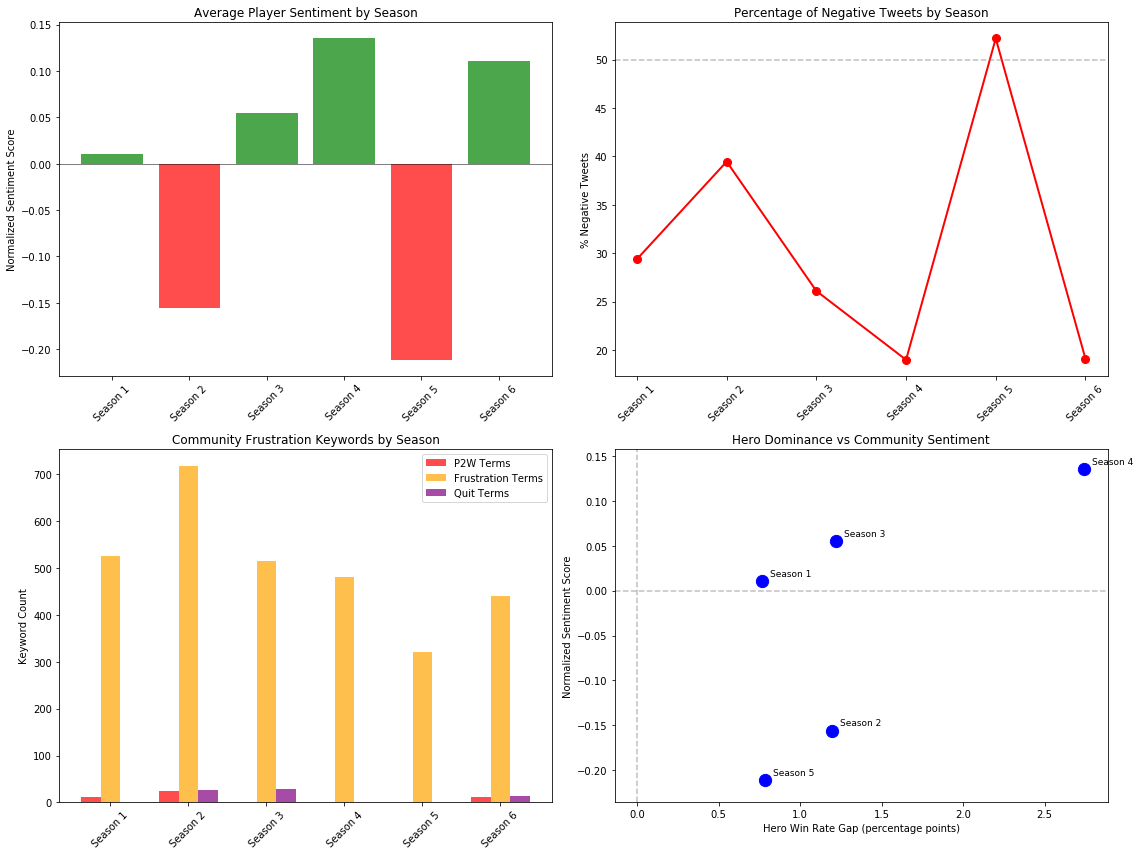

Figure saved


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

seasons_list = sentiment_final["season"].tolist()
x = range(len(seasons_list))

# Plot 1: Average normalized sentiment
colors = ["red" if s < 0 else "green" 
          for s in sentiment_final["avg_normalized_sentiment"]]
axes[0,0].bar(x, sentiment_final["avg_normalized_sentiment"], 
              color=colors, alpha=0.7)
axes[0,0].axhline(y=0, color="black", linewidth=0.5)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(seasons_list, rotation=45)
axes[0,0].set_ylabel("Normalized Sentiment Score")
axes[0,0].set_title("Average Player Sentiment by Season")

# Plot 2: Negative tweet percentage
axes[0,1].plot(x, sentiment_final["pct_negative"] * 100,
               marker="o", linewidth=2, markersize=8, color="red")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(seasons_list, rotation=45)
axes[0,1].set_ylabel("% Negative Tweets")
axes[0,1].set_title("Percentage of Negative Tweets by Season")
axes[0,1].axhline(y=50, color="gray", linestyle="--", alpha=0.5)

# Plot 3: Keyword frequencies
width = 0.25
axes[1,0].bar([i - width for i in x], 
              sentiment_final["p2w_terms"],
              width=width, label="P2W Terms", color="red", alpha=0.7)
axes[1,0].bar(x, sentiment_final["frustration_terms"],
              width=width, label="Frustration Terms", color="orange", alpha=0.7)
axes[1,0].bar([i + width for i in x],
              sentiment_final["quit_terms"],
              width=width, label="Quit Terms", color="purple", alpha=0.7)
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(seasons_list, rotation=45)
axes[1,0].set_ylabel("Keyword Count")
axes[1,0].set_title("Community Frustration Keywords by Season")
axes[1,0].legend()

# Plot 4: Sentiment vs hero win rate gap
pop_df = pd.read_csv(r"C:\Users\asawe\CRProject\hero_winrate_results.csv")
seasons_overlap = ["Season 1", "Season 2", "Season 3", "Season 4", "Season 5"]
sentiment_overlap = sentiment_final[
    sentiment_final["season"].isin(seasons_overlap)
].reset_index(drop=True)

for i, row in sentiment_overlap.iterrows():
    axes[1,1].scatter(
        pop_df["winrate_gap"].iloc[i] * 100,
        row["avg_normalized_sentiment"],
        s=150, color="blue", zorder=5
    )
    axes[1,1].annotate(
        seasons_overlap[i],
        (pop_df["winrate_gap"].iloc[i] * 100,
         row["avg_normalized_sentiment"]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=9
    )

axes[1,1].set_xlabel("Hero Win Rate Gap (percentage points)")
axes[1,1].set_ylabel("Normalized Sentiment Score")
axes[1,1].set_title("Hero Dominance vs Community Sentiment")
axes[1,1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[1,1].axvline(x=0, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(r"C:\Users\asawe\Documents\CR_Project\sentiment_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved")

In [13]:
sentiment_final.to_csv(
    r"C:\Users\asawe\Documents\CR_Project\sentiment_by_season.csv",
    index=False
)
print("Sentiment data saved")
print("\nAll analysis complete!")
print("\nFiles saved:")
print("- hero_winrate_results.csv")
print("- hero_usage_results.csv") 
print("- individual_hero_winrates.csv")
print("- elite_winrate_results.csv")
print("- sentiment_by_season.csv")
print("- hero_winrate_analysis.png")
print("- hero_usage_analysis.png")
print("- elite_vs_population_comparison.png")
print("- sentiment_analysis.png")

Sentiment data saved

All analysis complete!

Files saved:
- hero_winrate_results.csv
- hero_usage_results.csv
- individual_hero_winrates.csv
- elite_winrate_results.csv
- sentiment_by_season.csv
- hero_winrate_analysis.png
- hero_usage_analysis.png
- elite_vs_population_comparison.png
- sentiment_analysis.png
